# Personal Information
Name: Marit van den Helder

StudentID: 13970097

Email: [marit.van.den.helder@student.uva.nl](marit.van.den.helder@student.uva.nl)

Submitted on: 23.03.2026

[GitHub](https://github.com/Marit-vdh/master-thesis.git)

# Data Context
NH Nieuws publishes local news from the Noord Holland province in the Netherlands. Articles range from updates on emergencies, to reports of sport matches to interviews with locals. All articles are written in Dutch, but often have automatic translations available. In some cases, a 'translation' to an easier level of Dutch is also available. 

The main dataset consists of the written articles published by NH Nieuws. The individual articles are available in a JSON format. Each article has all its metadata included, such as the author, date of publishing and type of article. The text is given in a structured format, meaning title, summary, headers and paragraphs are easily individually accessible.

The goal of the thesis is to create an improved information retrieval system for the internal content management system. The general approach will include both the integration of traditional retrieval techniques (such as an exploration of TF-IDF) and more recent LLM integrations (such as RAG).

# Data Description

The total number of articles in the dataset is 298202, constituting to a dataset size of approximately 2.2 GB. Over time, both the number of articles produced, as well as the sizes of the files and the lengths of the articles increase. The most commonly used words are mostly words wich are common in the Dutch language in general ('de', 'het', 'is', etc.). A notable exception is the word 'Amsterdam'. This makes sense in the context of NH Nieuws, since Amsterdam is located in the province of Noord Holland. Other notable exceptions in the top 100 most common words are 'politie' (police) and 'gemeente' (municipality), indicating which topics NH Nieuws covers the most.

In [1]:
# !pip install bs4

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
from bs4 import BeautifulSoup
from nltk import word_tokenize
from nltk.stem.snowball import SnowballStemmer

### Data Sample

In [3]:
# Data sample
with open('bruinvis.json', 'r') as file:
    data = json.load(file)

print(json.dumps(data, indent=4))

{
    "data": {
        "type": "article",
        "id": "357903",
        "attributes": {
            "workflow": 0,
            "online_date": "2026-03-11T19:00:00+00:00",
            "offline_date": null,
            "title": "Gestrande bruinvissen maken het goed en zwemmen zelfstandig bij SOS Dolfijn",
            "alternative_title": "",
            "template": "nieuws_artikel",
            "show_ads": true,
            "comments": false,
            "not_suitable_content": false,
            "push_message_sent": false,
            "slug": "gestrande-bruinvissen-maken-het-goed-en-zwemmen-zelfstandig-bij-sos-dolfijn",
            "image_id": 573571,
            "region_id": 45,
            "region_text": "Anna Paulowna",
            "sent_to_rpo": true,
            "deleted": false,
            "changed": "2026-03-11T20:37:52+00:00",
            "meta_description": "Gestrande bruinvissen op Vlieland herstellen goed bij SOS Dolfijn in Anna Paulowna: dieren zwemmen zelfstandig en ete

### Overview of quantities of the data 

In [4]:
# Retrieve all article names from the directory
folders = os.listdir('../../articles')

article_names = {}

for folder in folders:
    months = os.listdir(f'../../articles/{folder}')

    article_names[int(folder)] = {}

    for month in months:
        article_names[int(folder)][month] = set(os.listdir(f'../../articles/{folder}/{month}'))

print(article_names[2023]['01'])

{'313467.json', '313585.json', '314147.json', '313946.json', '313294.json', '312953.json', '313803.json', '313591.json', '313374.json', '314056.json', '313834.json', '313136.json', '313260.json', '313060.json', '313760.json', '313711.json', '312983.json', '313270.json', '312912.json', '313767.json', '313863.json', '313346.json', '313390.json', '313503.json', '313214.json', '313439.json', '313499.json', '313730.json', '313984.json', '313402.json', '313686.json', '313464.json', '314031.json', '313935.json', '314044.json', '313913.json', '314037.json', '313156.json', '313841.json', '313143.json', '313623.json', '314069.json', '313066.json', '313292.json', '313149.json', '314055.json', '313268.json', '314113.json', '313719.json', '314140.json', '313771.json', '313559.json', '313417.json', '313567.json', '312942.json', '313308.json', '313631.json', '314146.json', '313918.json', '314166.json', '313167.json', '313350.json', '313524.json', '313752.json', '313525.json', '313088.json', '314118.j

In [5]:
# Plot the number of articles per year
n_articles = []
for year in sorted(list(article_names.keys())):
    article_sum = 0

    for month, articles in article_names[year].items():
        article_sum += len(articles)
    
    n_articles.append(article_sum)

print(n_articles)
print('Total number of articles:', sum(n_articles))

[80, 67, 4088, 14936, 11222, 11246, 10482, 11840, 11342, 17328, 20845, 17658, 17826, 17231, 19555, 20941, 17507, 16964, 14566, 16010, 13570, 10637, 2261]
Total number of articles: 298202


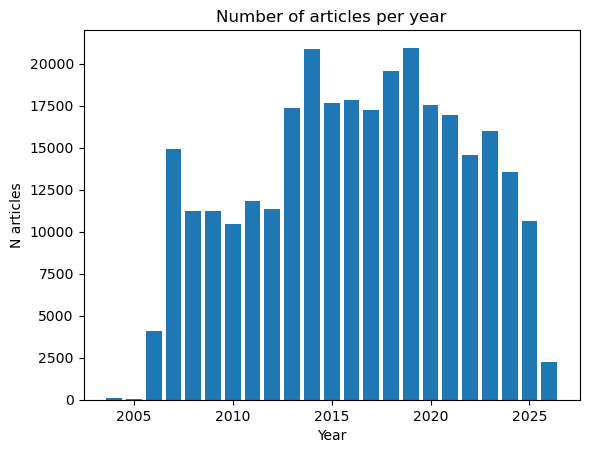

In [6]:
plt.bar(sorted(article_names.keys()), 
        height=n_articles)
plt.xlabel('Year')
plt.ylabel('N articles')
plt.title("Number of articles per year")
plt.show()

In [7]:
# Show the average file sizes as a proxy for article length to see if there is a change over time
cum_filesize = []
for year in sorted(list(article_names.keys())):
    size_sum = 0

    for month, articles in article_names[year].items():

        for article in articles:
            size_sum += os.path.getsize(f'../../articles/{year}/{month}/{article}')
    
    cum_filesize.append(size_sum)

print(cum_filesize)
print('Total dataset size:', sum(cum_filesize))

[256506, 212232, 15735779, 59996884, 47717674, 50313274, 48410086, 59502798, 57808300, 89222153, 110365461, 104568251, 101412281, 100926558, 118458305, 147169931, 171684902, 187773360, 177205882, 201083097, 176198818, 145346974, 30064278]
Total dataset size: 2201433784


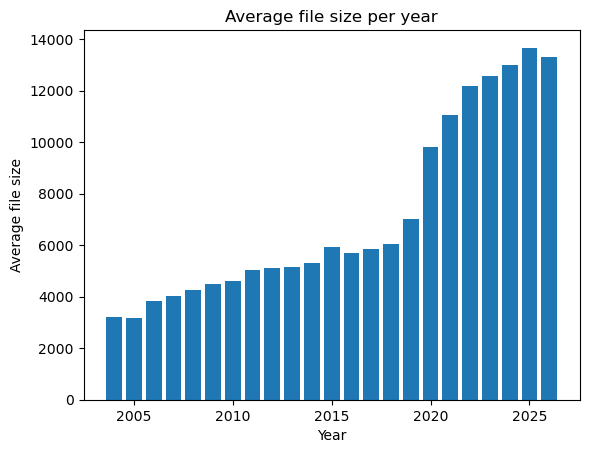

In [8]:
height = np.divide(np.array(cum_filesize), np.array(n_articles))

plt.bar(sorted(article_names.keys()), 
        height=height)
plt.xlabel('Year')
plt.ylabel('Average file size')
plt.title("Average file size per year")
plt.savefig('average_filesize_per_year.pdf', format='pdf')
plt.show()

### Insight in the file structure and word counts

In [9]:
article_text = {}

for year in os.listdir('../../articles/'):    

    article_text[year] = {}

    for month in os.listdir(f'../../articles/{year}'):

        article_text[year][month] = {}

        for article_name in os.listdir(f'../../articles/{year}/{month}'):

            # Retrieve the flat text
            with open(f'../../articles/{year}/{month}/{article_name}', mode='r', encoding='utf-8') as file:
                
                article = json.load(file)

                text = ''

                for section in article['included']:

                    # Text is stored in two different types of blocks
                    if section['type'] in {'block-intro', 'block-text'}:

                        # Clean the text with the BeautifulSoup module
                        parsed = BeautifulSoup(section['attributes']['text'], "html.parser")
                        text += parsed.get_text()

                # Add text to dictionary, remove .json extension
                article_text[year][month][article_name[:-5]] = text

print(article_text.keys())

dict_keys(['2019', '2018', '2015', '2004', '2016', '2025', '2020', '2024', '2008', '2013', '2023', '2026', '2009', '2011', '2007', '2005', '2006', '2010', '2022', '2017', '2021', '2014', '2012'])


In [10]:
article_lengths = {}

for year in article_text.keys():

    article_lengths[year] = {}

    for month in article_text[year].keys():

        article_lengths[year][month] = {}

        for article in article_text[year][month].keys():
            
            # Split the text into individual words using nltk tokenizer
            tokenized = word_tokenize(article_text[year][month][article])

            article_lengths[year][month][article] = len(tokenized)

print(article_lengths['2009']['01'])

{'32220': 120, '24467': 70, '27350': 133, '40512': 42, '12553': 48, '26968': 90, '22128': 80, '9262': 94, '36376': 103, '18594': 268, '47192': 138, '2939': 95, '42127': 91, '19196': 75, '43528': 84, '8719': 376, '3033': 77, '938': 48, '45880': 79, '13627': 90, '26756': 99, '1461': 84, '33595': 45, '42986': 46, '10797': 100, '21098': 98, '41130': 102, '21868': 87, '48786': 56, '33966': 39, '22064': 46, '11172': 89, '29574': 50, '48186': 43, '43993': 85, '47258': 41, '27085': 84, '16095': 102, '38032': 93, '24992': 95, '27636': 92, '2320': 38, '20850': 88, '12786': 89, '31712': 159, '29367': 94, '3476': 296, '34615': 324, '29793': 47, '6427': 67, '34287': 44, '36832': 82, '46952': 93, '40307': 97, '24354': 270, '17174': 100, '41810': 38, '3218': 39, '15752': 43, '36077': 84, '27977': 115, '39864': 97, '26321': 43, '23872': 423, '9144': 46, '24568': 50, '27476': 102, '28632': 91, '26637': 40, '28309': 42, '28214': 132, '28890': 60, '2398': 47, '48691': 105, '24455': 104, '9157': 47, '4083

In [11]:
# Show the average number of words per year
cum_word_count = []

for year in sorted(list(article_lengths.keys())):
    
    size_sum = 0

    for month, articles in article_lengths[year].items():

        for article in articles:
            size_sum += article_lengths[year][month][article]
    
    cum_word_count.append(size_sum)

print(cum_word_count)

[2042, 2119, 308272, 1111248, 960854, 1218127, 1309889, 1784084, 1680611, 2527460, 3292037, 3210245, 3373352, 3614588, 4417790, 5314495, 5118229, 5571398, 5144121, 5911560, 5019169, 3726303, 676499]


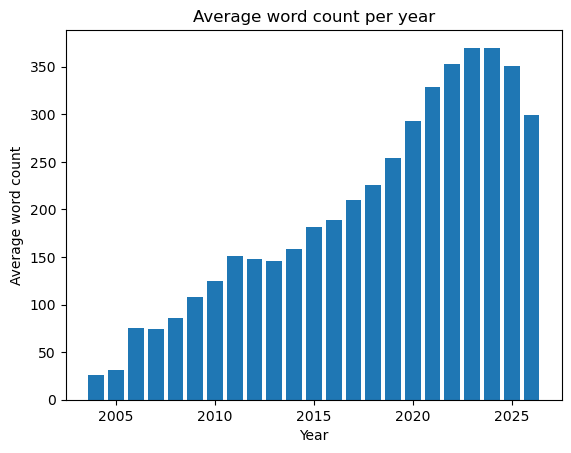

In [12]:
height = np.array(cum_word_count) / np.array(n_articles)

plt.bar(sorted(article_names.keys()), 
        height=height)
plt.xlabel('Year')
plt.ylabel('Average word count')
plt.title("Average word count per year")
plt.savefig('average_wordcount_per_year.pdf', format='pdf')
plt.show()

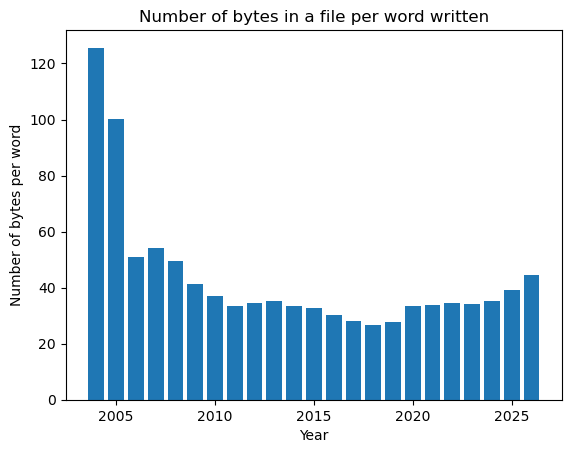

In [13]:
height = (np.divide(np.array(cum_filesize), np.array(n_articles))) / (np.array(cum_word_count) / np.array(n_articles))

plt.bar(sorted(article_names.keys()), 
        height=height)
plt.xlabel('Year')
plt.ylabel('Number of bytes per word')
plt.title("Number of bytes in a file per word written")
plt.savefig('bytes_per_word_per_year.pdf', format='pdf')
plt.show()

In [14]:
# # Count the number of occurrences of each word
# word_counts = {}
# stemmer = SnowballStemmer('dutch')
# from nltk.corpus import wordnet as wn
# import spacy
# from nltk.corpus import stopwords

# stopwords_list = stopwords.words('dutch')

# nlp = spacy.load("nl_core_news_lg")

# def lemmatizer(text):
#     pass


# for year in list(article_text.keys())[:1]:
#     for month in list(article_text[year].keys())[:1]:
#         for article in list(article_text[year][month].keys())[:5]:
            
#             lemmatized_text = nlp.pipe([article_text[year][month][article]])
#             print(list(lemmatized_text))
            
#             # Count the words
#             # word_counts[lemma] = word_counts.get(lemma, 0) + 1

# print(list(word_counts.keys()))

In [15]:
# Show the most common words
sorted_counts = sorted(word_counts, key=word_counts.get, reverse=True)

print(f"{'Rank':<5} | {'Word':<10} | {'Count':>10}")
print("-" * 6, "-" * 12, "-" * 11)

rank  = 1

for word in sorted_counts[0:100]:
    print(f"{rank:<5} | {word:<10} | {word_counts[word]:>10}")
    rank += 1


NameError: name 'word_counts' is not defined

## Article types

In [28]:
# Extract the article type counts per year
article_types = {}

for year in os.listdir('../../articles/'):   

    article_types[year] = {}

    for month in os.listdir(f'../../articles/{year}'):

        article_types[year][month] = {}

        for article_name in os.listdir(f'../../articles/{year}/{month}'):

            # Retrieve the article types 
            with open(f'../../articles/{year}/{month}/{article_name}', mode='r', encoding='utf-8') as file:
                
                article = json.load(file)

                for section in article['included']:

                    # Text is stored in two different types of blocks
                    if section['type'] == 'article-category':

                        article_types[year][month][section['attributes']['name']] = article_types[year][month].get(section['attributes']['name'], []) + [article['data']['id']]


                # for category in article['data']['relationships']['categories']['data']:
                #     article_types[year][month][category['id']] = article_types[year][month].get(category['id'], []) + [article['data']['id']]

print(article_types['2019'])

['2019', '2018', '2015', '2004', '2016', '2025', '2020', '2024', '2008', '2013', '2023', '2026', '2009', '2011', '2007', '2005', '2006', '2010', '2022', '2017', '2021', '2014', '2012']
{'12': {'Nieuws': ['258311', '258074', '259084', '258231', '259066', '258335', '258319', '259260', '258064', '257849', '259258', '258261', '258898', '258668', '258132', '258585', '257921', '258077', '258894', '258800', '258306', '258840', '258557', '257978', '259073', '258392', '258105', '258651', '258793', '259224', '258308', '258190', '259123', '258879', '258885', '257690', '258435', '257738', '257965', '259282', '258657', '257821', '258749', '257665', '258280', '257734', '258788', '259234', '258684', '258037', '258593', '258489', '258747', '259129', '259210', '258667', '258960', '258103', '258082', '258247', '259169', '259184', '258910', '258500', '259166', '258495', '257828', '258000', '258933', '258756', '258695', '258852', '259060', '258468', '257874', '259257', '258705', '259146', '258365', '25908

In [29]:
# Show the number of times a category is used per year
category_count = {}

for year in sorted(list(article_types.keys())):
    
    for month, types in article_types[year].items():

        for article_type in types:
            category_count[article_type] = category_count.get(article_type, 0) + len(types[article_type])
    
print(category_count)

{'Nieuws': 206493, 'Sport': 60757, 'Extra': 2209, 'Alkmaar': 12874, 'Noordkop & Texel': 9563, 'Amsterdam': 28270, 'Schiphol': 3084, 'Amstelland': 5953, 'Haarlem': 10911, 'Zaanstreek-Waterland': 11872, 'Het Gooi': 11302, 'IJmond': 8846, 'West-Friesland': 13467, 'Verkiezingen': 202, 'Haarlemmermeer': 2105, 'DONOTUSE': 541}


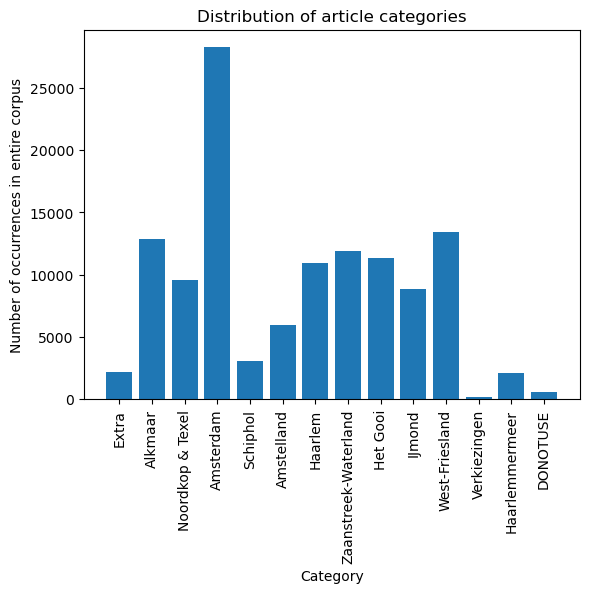

In [35]:
ids = []
heights = []

for article_type, count in category_count.items():
    ids.append(article_type)
    heights.append(count)
    
plt.bar(ids[2:], 
        height=heights[2:])
plt.xticks(rotation='vertical')
plt.xlabel('Category')
plt.ylabel('Number of occurrences in entire corpus')
plt.title("Distribution of article categories")
plt.savefig('article_type_distribution.pdf', format='pdf', bbox_inches='tight')
plt.show()